# ex-h1 — Does hedging the *whole* factor block kill rotation error?

**The question (N.):** hedging one factor against one estimated direction is a
*Stiefel* operation — it pairs $h_j$ with $\bar b_j$ — so it carries the full
per-factor error $\sin^2\angle(h_j,\bar b_j)$, rotation term included, and
Theorem 3 says that rotation term is essentially unconstrained by the data.
Hedging all $k$ factors at once — regress the book on the $k$ estimated
factor-mimicking portfolios, trade the opposite coefficients — is instead a
*Grassmannian* operation: it sees $\mathrm{col}(H)$ only. Does rotation error
drop out?

**Answer this notebook establishes: yes, exactly — and the residual that remains
is the estimable out-of-subspace term alone.**

Everything reduces to one $k\times k$ matrix. With both frames orthonormal, let

$$M = \bar B H \in \mathbb{R}^{k\times k},\qquad M_{ij}=\langle \bar b_i, h_j\rangle .$$

Then

$$\underbrace{\textstyle\sum_j \sin^2\angle(h_j,\bar b_j) = k-\sum_j M_{jj}^2}_{\text{pairwise (Stiefel)}},
\qquad
\underbrace{\textstyle\sum_j \sin^2\angle(h_j,\mathcal{B}) = k-\lVert M\rVert_F^2=\tfrac12\lVert \Pi_H-\Pi_{\mathcal{B}}\rVert_F^2}_{\text{subspace (Grassmann)}} .$$

Rotating the estimated frame inside its own span sends $H\mapsto HQ$, i.e.
$M\mapsto MQ$. **The Frobenius norm is invariant; the diagonal is not.** That
single line is the whole claim, and every figure below is a measurement of it.

**What is *not* claimed:** the block hedge does not make the mis-hedge zero. It
removes the rotation contribution and leaves an out-of-subspace floor — one set
by $n$, not by $p$ — for which Corollary 1 supplies a data-only ceiling
$\sqrt{\sum_j \hat\ell/\hat\theta_j}$. The last section quantifies exactly how
much is thereby given up, and flags where the argument does *not* apply.

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim"), str(REPO_ROOT / "hedging")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from IPython.display import Image, display

from fl_plot import THEME, sweep_axis, summarize, rep_dists, save as save_fig
from fl_experiment_setup import ModelSpec, DesignSpec, build_model, simulate_returns
from fl_experiment_runner import run_experiment
from factor_lab.analyses.spectral import compute_true_eigenvalues
from hedge_lab import (
    sample_pcs, cross_gram, subspace_geometry, regression_hedge_coefficients,
    hedge, worst_case_portfolio, cyclic_relabel, random_rotation,
    adversarial_rotation, standard_portfolios, HedgingExperiment,
)

from loguru import logger
logger.remove()                       # keep the sweep quiet inside the notebook

OUT_DIR = REPO_ROOT / "nb_outputs" / "hedging"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_FORMATS = ("pdf",)
SAVE_FIGS = False    # default: nothing written to disk; enable per figure with out(..., save=True)

def out(stem, save=None):
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None

def show(fig, stem=None, save=None):
    path = out(stem, save) if stem else None
    if path is not None:
        save_fig(fig, path, formats=FIG_FORMATS)
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)

# ── Colors carry meaning, reused from the paper's figure theme ────────────────
# blue  = out-of-subspace / rotation-free  (THEME.oos_fill, as in ex-2 / ex-3)
# orange= in-subspace rotation             (THEME.insub_fill)
# red   = the observable statistic l/theta (as in the ex-3 overlays)
C_SUB, C_ROT = THEME.oos_fill, THEME.insub_fill
C_SUB_LINE, C_ROT_LINE = THEME.oos_line, THEME.insub_line
C_EST, C_REF = "#d62728", "0.35"

plt.rcParams.update({"axes.grid": True, "grid.color": THEME.grid_color,
                     "grid.linewidth": 0.7, "axes.axisbelow": True,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 110})

def style(ax, ylabel=None, xlabel=None, title=None):
    # Only sets what it is handed, so a later style(ax, ylabel=...) cannot wipe
    # an xlabel set earlier in the same figure.
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=THEME.label_fontsize)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=THEME.label_fontsize)
    if title is not None:
        ax.set_title(title, fontsize=THEME.title_fontsize, color=THEME.navy)
    return ax

def caption(fig, text):
    # tight_layout first, so the caption clears the x-axis label.
    fig.tight_layout()
    fig.text(0.5, -0.04, text, ha="center", va="top",
             fontsize=THEME.caption_fontsize, color=THEME.gray, wrap=True)

print("repo root:", REPO_ROOT)

repo root: /Users/alex/Documents/Finance_Projects/factor_lab_pc_concentration_code


---
## 1 · One replicate, four frames

Build the canonical diagonal-Gram model ($k=3$, market-like factor 1), draw one
panel of returns, and take the sample PCs $H$. Then look at the *same subspace*
through four different orthonormal frames:

| frame | what it is |
|---|---|
| `pca` | the PCs as the eigensolver orders them |
| `relabel` | $h_j \leftarrow h_{j+1}$ — "you're mimicking *a* factor, just not the one you named" |
| `random` | a Haar-random $Q$ mixing the three directions |
| `adversarial` | $Q$ chosen to **maximize** the pairwise error $\sum_j\sin^2\angle$ |

All four span an identical $\mathrm{col}(H)$. A Stiefel-level reading of the
error sees four different worlds; a Grassmannian one sees a single number.

In [2]:
K, P_DEMO, N_DEMO = 3, 5_000, 63
model_spec = ModelSpec()          # k=3, factor vols [.16,.08,.06], idio vol 0.4

rng = np.random.default_rng(20260511)
demo_model = build_model(model_spec, P_DEMO, rng)
ctx = simulate_returns(demo_model, N_DEMO,
                       {"distribution": "normal", "loc": 0.0, "scale": 1.0},
                       {"distribution": "normal", "loc": 0.0, "scale": 1.0}, K, rng)

Y = ctx.security_returns.T                       # (p, n)
Y = Y - Y.mean(axis=1, keepdims=True)            # row-demean: the MLE convention
H, theta, ell = sample_pcs(Y, K, center=False)
_, b_pop = compute_true_eigenvalues(demo_model, K)

# The true factor subspace is the row space of B; with constant idiosyncratic
# vol the top-k eigenvectors of Sigma span exactly that, which is worth checking
# rather than assuming, since every "out-of-subspace" number below depends on it.
U_B = np.linalg.svd(demo_model.B.T, full_matrices=False)[0]
print(f"span(b_pop) vs span(B'):  k - ||b_pop U_B||_F^2 = {K - ((b_pop @ U_B)**2).sum():.2e}")

FRAMES = {
    "pca":         H,
    "relabel":     cyclic_relabel(H),
    "random":      H @ random_rotation(K, np.random.default_rng(11)),
    "adversarial": H @ adversarial_rotation(b_pop, H),
}

rows = []
w_demo = standard_portfolios(P_DEMO)["equal_weight"]
for name, Hf in FRAMES.items():
    g = subspace_geometry(b_pop, Hf)
    rows.append({
        "frame": name,
        "pairwise  sum sin2(h_j, b_j)": g["pair_sum"],
        "subspace  sum sin2(h_j, B)":   g["oos_sum"],
        "||Pi_H - Pi_B||_F^2":          g["subspace_dist_fro2"],
        "block hedge resid (m=k)":      np.linalg.norm(b_pop @ hedge(w_demo, Hf)),
        "partial hedge resid (m=1)":    np.linalg.norm(b_pop @ hedge(w_demo, Hf, 1)),
    })
demo_tbl = pd.DataFrame(rows).set_index("frame")
display(demo_tbl.round(6))

spread = demo_tbl["subspace  sum sin2(h_j, B)"].max() - demo_tbl["subspace  sum sin2(h_j, B)"].min()
print(f"\npairwise error ranges over  {demo_tbl['pairwise  sum sin2(h_j, b_j)'].min():.3f}"
      f" .. {demo_tbl['pairwise  sum sin2(h_j, b_j)'].max():.3f}   (k = {K} is the maximum)")
print(f"subspace error ranges over  {spread:.2e}   <- invariant, to machine precision")

span(b_pop) vs span(B'):  k - ||b_pop U_B||_F^2 = 4.44e-15


,"pairwise sum sin2(h_j, b_j)","subspace sum sin2(h_j, B)",||Pi_H - Pi_B||_F^2,block hedge resid (m=k),partial hedge resid (m=1)
frame,,,,,
pca,0.828645,0.805407,1.610815,0.072931,0.106800
relabel,2.988989,0.805407,1.610815,0.072931,0.896640
random,2.713214,0.805407,1.610815,0.072931,0.889213
adversarial,3.000000,0.805407,1.610815,0.072931,0.897358



pairwise error ranges over  0.829 .. 3.000   (k = 3 is the maximum)
subspace error ranges over  5.11e-15   <- invariant, to machine precision


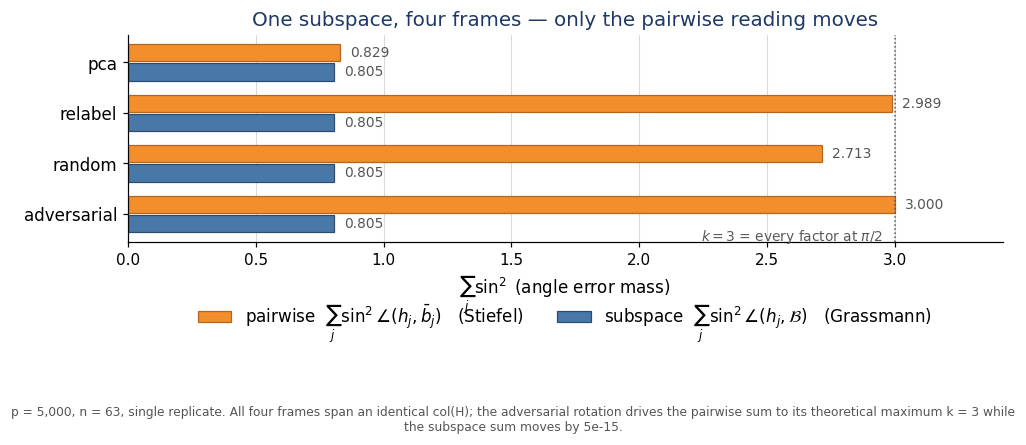

In [3]:
# ── Figure 1 · the same subspace, four frames ────────────────────────────────
fr = list(FRAMES)
y = np.arange(len(fr))[::-1]
pair = demo_tbl["pairwise  sum sin2(h_j, b_j)"].to_numpy()
oos  = demo_tbl["subspace  sum sin2(h_j, B)"].to_numpy()

fig, ax = plt.subplots(figsize=(9.2, 3.6))
h = 0.34
ax.barh(y + h/2 + 0.02, pair, height=h, color=C_ROT, edgecolor=C_ROT_LINE, lw=0.8,
        label=r"pairwise  $\sum_j \sin^2\angle(h_j,\bar b_j)$   (Stiefel)")
ax.barh(y - h/2 - 0.02, oos, height=h, color=C_SUB, edgecolor=C_SUB_LINE, lw=0.8,
        label=r"subspace  $\sum_j \sin^2\angle(h_j,\mathcal{B})$   (Grassmann)")
for yy, v in zip(y + h/2 + 0.02, pair):
    ax.text(v + 0.04, yy, f"{v:.3f}", va="center", fontsize=9, color=THEME.gray)
for yy, v in zip(y - h/2 - 0.02, oos):
    ax.text(v + 0.04, yy, f"{v:.3f}", va="center", fontsize=9, color=THEME.gray)

ax.axvline(K, color=C_REF, lw=1.0, ls=":")
ax.text(K - 0.05, y.min() - 0.44, f"$k={K}$ = every factor at $\\pi/2$",
        ha="right", va="center", fontsize=9, color=C_REF)
ax.set_yticks(y, fr, fontsize=THEME.tick_fontsize)
ax.set_xlim(0, K + 0.42)
style(ax, xlabel=r"$\sum_j \sin^2$ (angle error mass)",
      title="One subspace, four frames — only the pairwise reading moves")
ax.legend(fontsize=THEME.legend_fontsize, frameon=False, ncol=2,
          loc="upper center", bbox_to_anchor=(0.5, -0.22))
ax.grid(axis="y", visible=False)
caption(fig, f"p = {P_DEMO:,}, n = {N_DEMO}, single replicate. All four frames span an identical col(H); "
             f"the adversarial rotation drives the pairwise sum to its theoretical maximum k = {K} "
             f"while the subspace sum moves by {spread:.0e}.")
show(fig, "h1_fig1_four_frames")

---
## 2 · The hedge a manager actually runs is a projection

Nothing above mentions a portfolio yet. The bridge is this: a manager who
regresses book returns $Yw$ on the estimated factor-mimicking returns $YH$ and
trades $-\hat\beta$ is doing pure data work — no $B$, no true exposure. Because
$H$ holds the *sample* PCs of that same $Y$, $H'Y'YH=\Lambda$ and $H'Y'Y=\Lambda H'$,
so $\hat\beta = H'w$ **exactly**, and the hedged book is $(I-\Pi_H)w$.

That is why the practical construction inherits the Grassmannian invariance:
$\Pi_{HQ}=\Pi_H$.

In [4]:
beta_reg = regression_hedge_coefficients(Y, w_demo, H)
print(f"regression coefficients      : {np.round(beta_reg, 8)}")
print(f"projection coefficients H'w  : {np.round(H.T @ w_demo, 8)}")
print(f"max |difference|             : {np.abs(beta_reg - H.T @ w_demo).max():.2e}\n")

base = hedge(w_demo, H)
for name, Hf in FRAMES.items():
    print(f"block-hedged book vs 'pca' book, frame {name:12s}: "
          f"max |w_h - w_h^pca| = {np.abs(hedge(w_demo, Hf) - base).max():.2e}")
print("\nThe hedged *book itself* — not merely its risk — is the same trade under every rotation.")

regression coefficients      : [ 0.86010428 -0.03172731  0.05583756]
projection coefficients H'w  : [ 0.86010428 -0.03172731  0.05583756]
max |difference|             : 1.44e-15

block-hedged book vs 'pca' book, frame pca         : max |w_h - w_h^pca| = 0.00e+00
block-hedged book vs 'pca' book, frame relabel     : max |w_h - w_h^pca| = 4.16e-17
block-hedged book vs 'pca' book, frame random      : max |w_h - w_h^pca| = 4.86e-17
block-hedged book vs 'pca' book, frame adversarial : max |w_h - w_h^pca| = 1.53e-16

The hedged *book itself* — not merely its risk — is the same trade under every rotation.


### How the invariance switches on with block size

Rotate the frame 300 different ways and hedge $m=1,2,\dots,k$ of the rotated
directions. For $m<k$ the manager is picking an $m$-dimensional slice *inside*
$\mathrm{col}(H)$, and which slice they get depends on the rotation — so the
outcome scatters. At $m=k$ the slice is the whole span, the choice disappears,
and the scatter collapses to zero width.

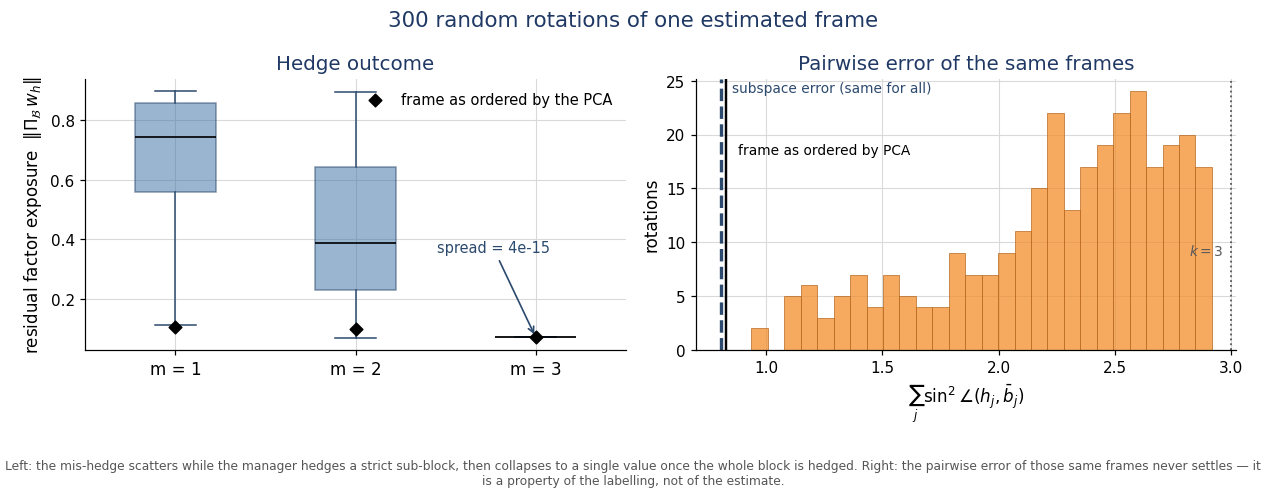

In [5]:
# ── Figure 2 · spread across random frames, by hedge block size ──────────────
rot_rng = np.random.default_rng(202609)
N_ROT = 300
resid_by_m = {m: [] for m in range(1, K + 1)}
pair_over_rot = []          # pairwise error does not depend on m, so it is one list
for _ in range(N_ROT):
    Hq = H @ random_rotation(K, rot_rng)
    pair_over_rot.append(subspace_geometry(b_pop, Hq)["pair_sum"])
    for m in range(1, K + 1):
        resid_by_m[m].append(np.linalg.norm(b_pop @ hedge(w_demo, Hq, m)))

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0))
ms = list(range(1, K + 1))

bp = axes[0].boxplot([resid_by_m[m] for m in ms], positions=ms, widths=0.45,
                     patch_artist=True, showfliers=False,
                     medianprops=dict(color="black", lw=1.1),
                     boxprops=dict(facecolor=C_SUB, alpha=0.55, edgecolor=C_SUB_LINE),
                     whiskerprops=dict(color=C_SUB_LINE), capprops=dict(color=C_SUB_LINE))
for m in ms:
    axes[0].scatter([m], [np.linalg.norm(b_pop @ hedge(w_demo, H, m))], s=34, zorder=6,
                    color="black", marker="D", label="frame as ordered by the PCA" if m == 1 else None)
w_at_k = np.ptp(resid_by_m[K])
axes[0].annotate(f"spread = {w_at_k:.0e}", xy=(K, np.mean(resid_by_m[K])),
                 xytext=(K - 0.55, np.mean(resid_by_m[K]) + 0.35 * np.ptp(resid_by_m[1])),
                 fontsize=9.5, color=C_SUB_LINE,
                 arrowprops=dict(arrowstyle="->", color=C_SUB_LINE, lw=1.1))
axes[0].set_xticks(ms, [f"m = {m}" for m in ms], fontsize=THEME.tick_fontsize)
style(axes[0], ylabel=r"residual factor exposure  $\Vert\Pi_{\mathcal{B}}\,w_h\Vert$",
      title="Hedge outcome")
axes[0].legend(fontsize=9.6, frameon=False, loc="upper right")

# The pairwise error has no m-dependence, so it is one distribution, not three.
oos_val = subspace_geometry(b_pop, H)["oos_sum"]
axes[1].hist(pair_over_rot, bins=28, color=C_ROT, alpha=0.75,
             edgecolor=C_ROT_LINE, lw=0.6)
axes[1].axvline(oos_val, color=C_SUB_LINE, lw=2.2, ls="--")
axes[1].axvline(subspace_geometry(b_pop, H)["pair_sum"], color="black", lw=1.6)
axes[1].axvline(K, color=C_REF, lw=1.2, ls=":")
ytop = axes[1].get_ylim()[1]
axes[1].text(oos_val + 0.05, ytop * 0.99, "subspace error (same for all)",
             ha="left", va="top", fontsize=9, color=C_SUB_LINE)
axes[1].text(subspace_geometry(b_pop, H)["pair_sum"] + 0.05, ytop * 0.72,
             "frame as ordered by PCA", fontsize=9, color="black")
axes[1].text(K - 0.03, ytop * 0.35, f"$k={K}$ ", ha="right", fontsize=9, color=C_REF)
style(axes[1], xlabel=r"$\sum_j \sin^2\angle(h_j,\bar b_j)$", ylabel="rotations",
      title="Pairwise error of the same frames")
fig.suptitle(f"{N_ROT} random rotations of one estimated frame",
             fontsize=THEME.title_fontsize + 1, color=THEME.navy)
fig.tight_layout()
caption(fig, "Left: the mis-hedge scatters while the manager hedges a strict sub-block, then collapses to a single "
             "value once the whole block is hedged. Right: the pairwise error of those same frames never settles — "
             "it is a property of the labelling, not of the estimate.")
show(fig, "h1_fig2_block_size_collapse")

---
## 3 · Sweeps

Now the same measurement across the $(n,p)$ grid, with the paper's design: one
shared true $B$, nested assets and time, 300 replicates. Rows carry `j = m`, the
hedged block size. Books are normalized to $\lVert w\rVert_2=1$ so residual
exposures are directly comparable to the operator-norm ceiling:

- `equal_weight` — flat book, heavily exposed to the market-like factor 1;
- `long_short` — Gaussian long-short, mostly idiosyncratic;
- `worst_case` — the unit book the block hedge serves worst, rebuilt per replicate.

In [6]:
N_REPS, SEED = 300, 20260511
P_GRID = [100, 500, 2000, 5000, 10_000, 20_000]
N_GRID = [20, 30, 45, 60, 63, 90, 120, 180, 250]

design_p = DesignSpec(n_values=[63], p_values=P_GRID, n_reps=N_REPS, random_seed=SEED,
                      sampling="nested", nest_time=True, shared_loadings=True)
design_n = DesignSpec(n_values=N_GRID, p_values=[3000], n_reps=N_REPS, random_seed=SEED,
                      sampling="nested", nest_time=True, shared_loadings=True)

_pq_p, _pq_n = OUT_DIR / "hedge_df_p.parquet", OUT_DIR / "hedge_df_n.parquet"
if _pq_p.exists() and _pq_n.exists():
    df_p, df_n = pd.read_parquet(_pq_p), pd.read_parquet(_pq_n)
    print("loaded cached hedging sweeps")
else:
    print("cache missing — running sweeps (a few minutes)...")
    df_p = run_experiment(model_spec, design_p, HedgingExperiment(p_max=max(P_GRID)), progress=True)
    df_n = run_experiment(model_spec, design_n, HedgingExperiment(p_max=3000), progress=True)
    df_p.to_parquet(_pq_p); df_n.to_parquet(_pq_n)

SWEEPS = [(df_p, "p", f"growing p, fixed n = 63"), (df_n, "n", "growing n, fixed p = 3,000")]
for d, key, lab in SWEEPS:
    print(f"{lab}: {int(d['rep'].max())+1} reps x {d[key].nunique()} {key}-values "
          f"x {d.j.nunique()} block sizes x {d.portfolio.nunique()} books = {len(d):,} rows")

# Invariance, now as a claim about every row of the sweep rather than one draw.
for d, key, lab in SWEEPS:
    full = d[d.j == K]
    print(f"{lab}: max |resid(natural frame) - resid(relabelled frame)| at m=k = "
          f"{(full.total_exposure - full.total_exposure_rot).abs().max():.2e}")

loaded cached hedging sweeps
growing p, fixed n = 63: 300 reps x 6 p-values x 3 block sizes x 3 books = 16,200 rows
growing n, fixed p = 3,000: 300 reps x 9 n-values x 3 block sizes x 3 books = 24,300 rows
growing p, fixed n = 63: max |resid(natural frame) - resid(relabelled frame)| at m=k = 2.29e-15
growing n, fixed p = 3,000: max |resid(natural frame) - resid(relabelled frame)| at m=k = 3.71e-15


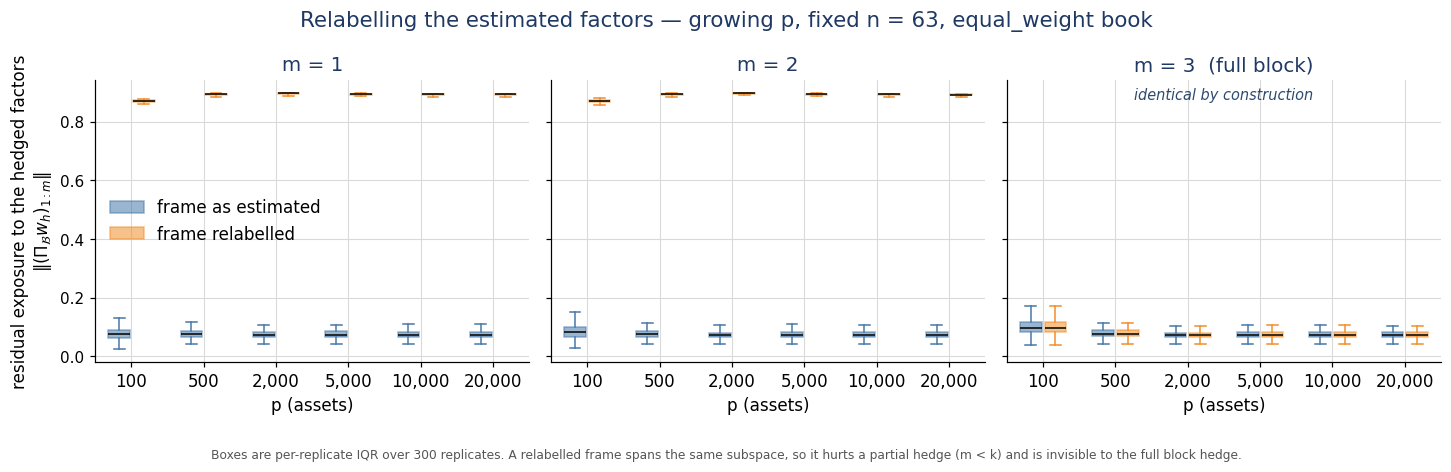

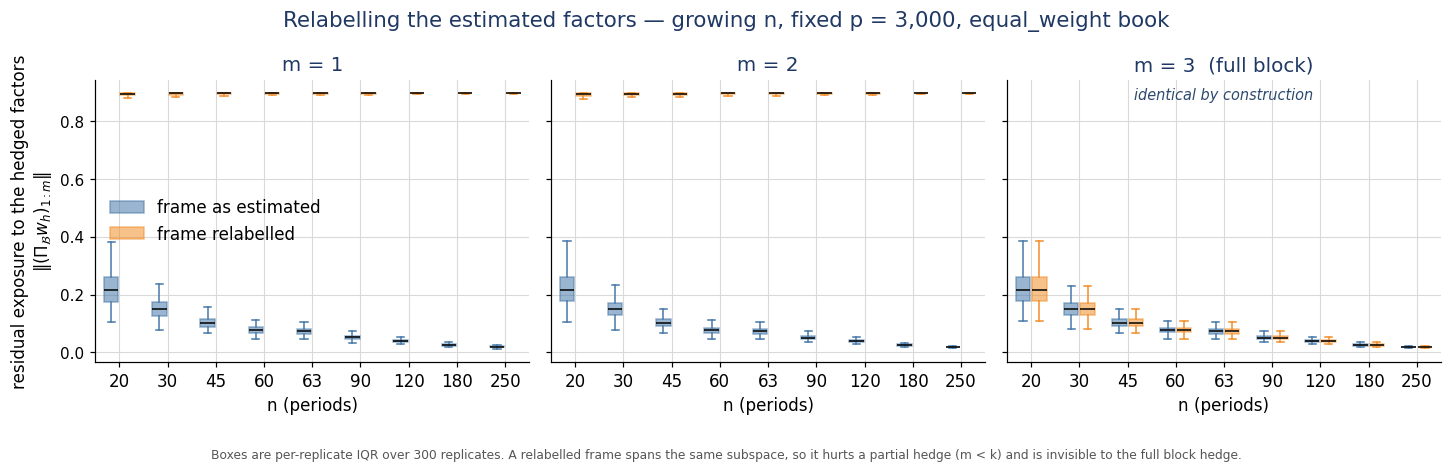

In [7]:
# ── Figure 3 · natural vs relabelled frame, by block size, across p ──────────
def paired_boxes(ax, ax_spec, dist_a, dist_b, color_a, color_b, width=0.3, gap=0.17):
    # Two boxplot series side by side at each swept value, with a surface gap.
    for dists, color, off in ((dist_a, color_a, -gap), (dist_b, color_b, +gap)):
        ax.boxplot(dists, positions=ax_spec.x + off, widths=width, patch_artist=True,
                   showfliers=False, zorder=3, medianprops=dict(color="black", lw=1.0),
                   boxprops=dict(facecolor=color, alpha=0.55, edgecolor=color),
                   whiskerprops=dict(color=color), capprops=dict(color=color))
    ax.set_xlim(ax_spec.x[0] - 0.5, ax_spec.x[-1] + 0.5)
    ax.set_xticks(ax_spec.x, ax_spec.cats, fontsize=THEME.tick_fontsize)

BOOK = "equal_weight"
for d, key, lab in SWEEPS:
    ax_spec = sweep_axis(d, key)
    fig, axes = plt.subplots(1, K, figsize=(13.3, 3.9), sharey=True)
    for i, m in enumerate(range(1, K + 1)):
        sub = d[(d.j == m) & (d.portfolio == BOOK)]
        paired_boxes(axes[i], ax_spec,
                     rep_dists(sub, ax_spec, "target_exposure"),
                     rep_dists(sub, ax_spec, "target_exposure_rot"),
                     C_SUB, C_ROT)
        title = f"m = {m}" + ("  (full block)" if m == K else "")
        style(axes[i], xlabel=ax_spec.xlabel, title=title)
        if m == K:
            axes[i].text(0.5, 0.93, "identical by construction", transform=axes[i].transAxes,
                         ha="center", fontsize=9.5, color=C_SUB_LINE, style="italic")
    style(axes[0], ylabel=r"residual exposure to the hedged factors" "\n"
                          r"$\Vert(\Pi_{\mathcal{B}}w_h)_{1:m}\Vert$")
    axes[0].legend(handles=[Patch(facecolor=C_SUB, alpha=0.55, edgecolor=C_SUB, label="frame as estimated"),
                            Patch(facecolor=C_ROT, alpha=0.55, edgecolor=C_ROT, label="frame relabelled")],
                   fontsize=THEME.legend_fontsize, frameon=False, loc="center left")
    fig.suptitle(f"Relabelling the estimated factors — {lab}, {BOOK} book",
                 fontsize=THEME.title_fontsize + 1, color=THEME.navy)
    fig.tight_layout()
    caption(fig, f"Boxes are per-replicate IQR over {int(d['rep'].max())+1} replicates. A relabelled frame spans the same "
                 "subspace, so it hurts a partial hedge (m < k) and is invisible to the full block hedge.")
    show(fig, f"h1_fig3_relabel_{key}")

### What fraction of the per-factor error is the part block hedging discards?

The Stiefel error splits as $\sin^2\angle(h_j,\bar b_j) = \underbrace{\sin^2\angle(h_j,\mathcal{B})}_{\text{out-of-subspace}} + \underbrace{\text{rotation}}_{\text{in-subspace}}$.
The block hedge pays the first and escapes the second.

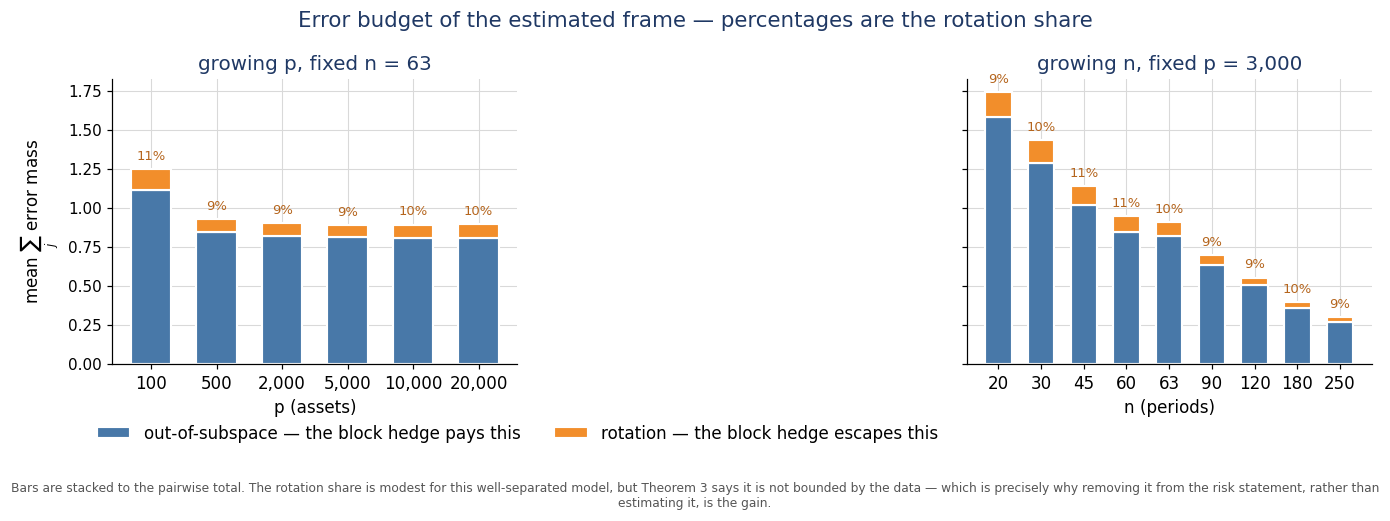

In [8]:
# ── Figure 4 · error budget: what the block hedge pays vs what it escapes ────
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2), sharey=True)
for ax, (d, key, lab) in zip(axes, SWEEPS):
    ax_spec = sweep_axis(d, key)
    one = d[(d.j == K) & (d.portfolio == BOOK)]
    oos = summarize(one, ax_spec, "oos_sum")["mean"].to_numpy()
    rot = summarize(one, ax_spec, "rot_sum")["mean"].to_numpy()
    # Segments are separated by a surface-colored edge rather than a data-space
    # offset, so the stacked heights still read as the true pairwise total.
    ax.bar(ax_spec.x, oos, width=0.62, color=C_SUB, edgecolor="white", lw=1.4,
           label="out-of-subspace — the block hedge pays this")
    ax.bar(ax_spec.x, rot, width=0.62, bottom=oos, color=C_ROT, edgecolor="white",
           lw=1.4, label="rotation — the block hedge escapes this")
    for x, a, b in zip(ax_spec.x, oos, rot):
        ax.text(x, a + b + 0.06, f"{100*b/(a+b):.0f}%", ha="center", fontsize=8.6, color=C_ROT_LINE)
    ax.set_xticks(ax_spec.x, ax_spec.cats, fontsize=THEME.tick_fontsize)
    style(ax, xlabel=ax_spec.xlabel, title=lab)
style(axes[0], ylabel=r"mean $\sum_j$ error mass")
axes[0].legend(fontsize=THEME.legend_fontsize, frameon=False, ncol=2,
               loc="upper center", bbox_to_anchor=(1.0, -0.16))
fig.suptitle("Error budget of the estimated frame — percentages are the rotation share",
             fontsize=THEME.title_fontsize + 1, color=THEME.navy)
fig.tight_layout()
caption(fig, "Bars are stacked to the pairwise total. The rotation share is modest for this well-separated model, "
             "but Theorem 3 says it is not bounded by the data — which is precisely why removing it from the "
             "risk statement, rather than estimating it, is the gain.")
show(fig, "h1_fig4_error_budget")

---
## 4 · The mis-hedge and its data-only ceiling

For any book, the hedged exposure obeys
$$\lVert\Pi_{\mathcal{B}}(I-\Pi_H)w\rVert \;\le\; \underbrace{\lVert\Pi_{\mathcal{B}}(I-\Pi_H)\rVert_2}_{\sin\theta_{\max}}\lVert w\rVert
\;\le\; \underbrace{\Big(\textstyle\sum_j \sin^2\angle(h_j,\mathcal{B})\Big)^{1/2}}_{\text{Corollary 1}}\lVert w\rVert ,$$
and Corollary 1's quantity is consistently estimated by $\sum_j\hat\ell/\hat\theta_j$
— **observable**. The `worst_case` book attains the first bound exactly, so the
gap between the curves is the real slack, not an artifact.

Worth naming what that worst-case book *is*: it is constructed inside
$\mathrm{range}(I-\Pi_H)$, so $\Pi_H w = 0$ — the estimated model sees **no**
factor exposure in it, the hedge is the identity on it, and it is left carrying
true exposure $\sin\theta_{\max}$. **The block hedge's blind spot is exactly the
set of books that look factor-neutral to the estimate but are not.** A manager
cannot detect such a book from the fit; the ceiling is what bounds it.

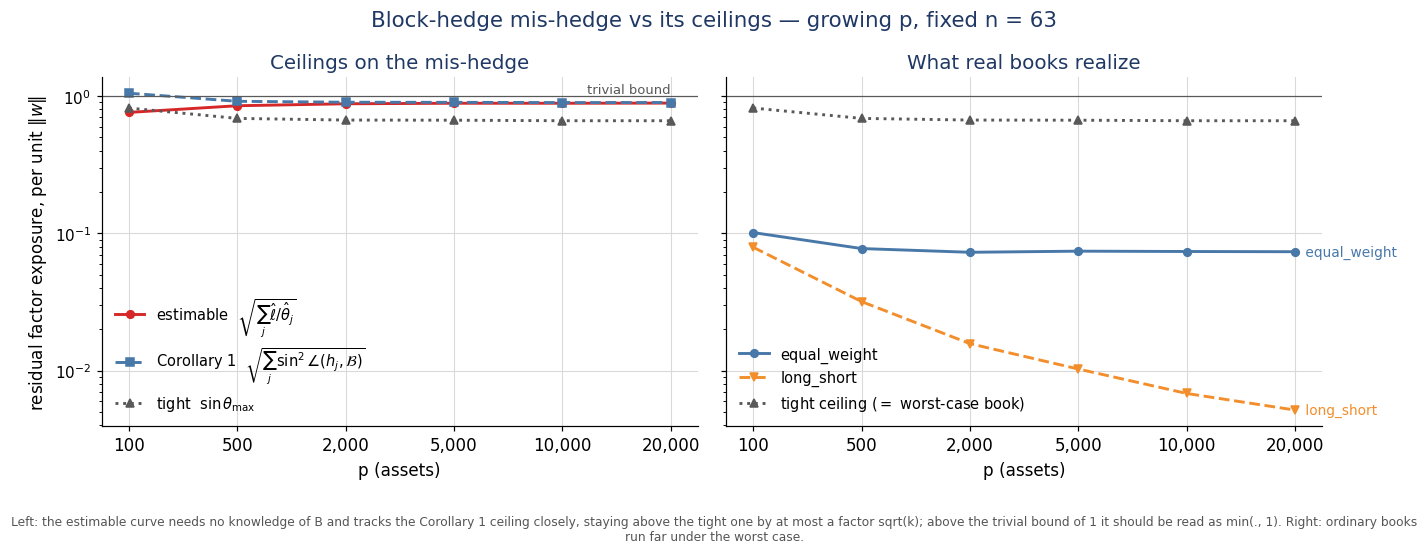

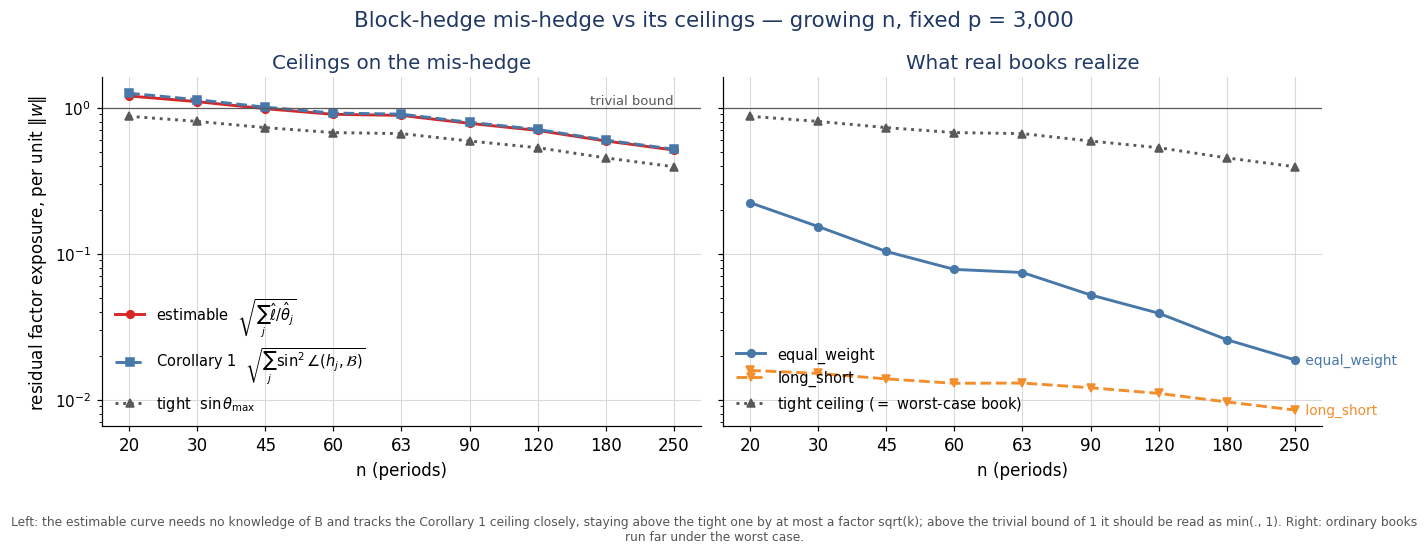

In [9]:
# ── Figure 5 · ceilings (left) and what books actually realize (right) ──────
# Split into two panels so that no two series inside one panel share a hue: the
# Corollary 1 ceiling and the realized equal-weight curve were both blue before,
# which read as one family when they are quite different objects.
for d, key, lab in SWEEPS:
    ax_spec = sweep_axis(d, key)
    full = d[d.j == K]
    wc = full[full.portfolio == "worst_case"]
    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5), sharey=True)

    for col, color, ls, mk, label in [
        ("ceiling_estimable", C_EST, "-", "o", r"estimable  $\sqrt{\sum_j \hat\ell/\hat\theta_j}$"),
        ("ceiling_measured", C_SUB, "--", "s", r"Corollary 1  $\sqrt{\sum_j \sin^2\angle(h_j,\mathcal{B})}$"),
        ("ceiling_tight", C_REF, ":", "^", r"tight  $\sin\theta_{\max}$"),
    ]:
        axes[0].plot(ax_spec.x, summarize(wc, ax_spec, col)["mean"], ls=ls, marker=mk,
                     ms=5, lw=1.9, color=color, label=label)
    style(axes[0], xlabel=ax_spec.xlabel,
          ylabel=r"residual factor exposure, per unit $\Vert w\Vert$",
          title="Ceilings on the mis-hedge")
    axes[0].legend(fontsize=9.6, frameon=False, loc="lower left")

    for book, color, mk, ls in (("equal_weight", C_SUB, "o", "-"),
                                ("long_short", C_ROT, "v", "--")):
        m = summarize(full[full.portfolio == book], ax_spec, "total_exposure")["mean"]
        axes[1].plot(ax_spec.x, m, ls=ls, marker=mk, ms=5, lw=1.9, color=color, label=book)
        axes[1].annotate(f" {book}", xy=(ax_spec.x[-1], m.iloc[-1]), xytext=(4, 0),
                         textcoords="offset points", fontsize=9, color=color, va="center")
    axes[1].plot(ax_spec.x, summarize(wc, ax_spec, "ceiling_tight")["mean"], ls=":",
                 marker="^", ms=5, lw=1.9, color=C_REF, label=r"tight ceiling ($=$ worst-case book)")
    style(axes[1], xlabel=ax_spec.xlabel, title="What real books realize")
    axes[1].legend(fontsize=9.6, frameon=False, loc="lower left")

    for ax in axes:
        ax.set_yscale("log")
        ax.set_xticks(ax_spec.x, ax_spec.cats, fontsize=THEME.tick_fontsize)
        ax.axhline(1.0, color=C_REF, lw=0.8)
    axes[0].text(ax_spec.x[-1], 1.06, "trivial bound", ha="right", fontsize=8.6, color=C_REF)
    fig.suptitle(f"Block-hedge mis-hedge vs its ceilings — {lab}",
                 fontsize=THEME.title_fontsize + 1, color=THEME.navy)
    caption(fig, "Left: the estimable curve needs no knowledge of B and tracks the Corollary 1 ceiling closely, "
                 "staying above the tight one by at most a factor sqrt(k); above the trivial bound of 1 it should "
                 "be read as min(., 1). Right: ordinary books run far under the worst case.")
    show(fig, f"h1_fig5_ceilings_{key}")

### The floor is set by $n$, not by $p$

This is the economically consequential part, and it is easy to misread. More
assets do **not** buy a cleaner block hedge: the out-of-subspace floor is a
statement about the length of the estimation window.

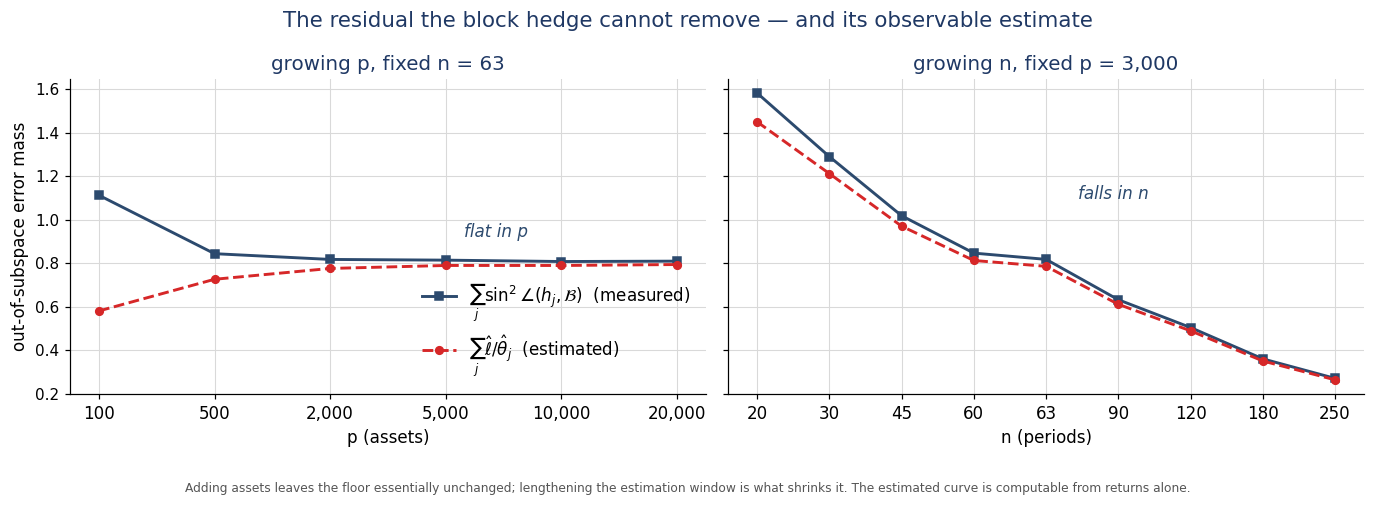

In [10]:
# ── Figure 6 · p buys nothing; n buys everything ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2), sharey=True)
for ax, (d, key, lab) in zip(axes, SWEEPS):
    ax_spec = sweep_axis(d, key)
    full = d[d.j == K]
    s_oos = summarize(full[full.portfolio == "worst_case"], ax_spec, "oos_sum")
    ax.plot(ax_spec.x, s_oos["mean"], marker="s", ms=5, lw=1.9, color=C_SUB_LINE,
            label=r"$\sum_j \sin^2\angle(h_j,\mathcal{B})$  (measured)")
    s_est = summarize(full[full.portfolio == "worst_case"], ax_spec, "ell_over_theta_sum")
    ax.plot(ax_spec.x, s_est["mean"], marker="o", ms=5, lw=1.9, ls="--", color=C_EST,
            label=r"$\sum_j \hat\ell/\hat\theta_j$  (estimated)")
    ax.set_xticks(ax_spec.x, ax_spec.cats, fontsize=THEME.tick_fontsize)
    style(ax, xlabel=ax_spec.xlabel, title=lab)
style(axes[0], ylabel="out-of-subspace error mass")
axes[0].legend(fontsize=THEME.legend_fontsize, frameon=False, loc="lower right")
axes[0].annotate("flat in p", xy=(0.62, 0.5), xycoords="axes fraction",
                 fontsize=11, color=C_SUB_LINE, style="italic")
axes[1].annotate("falls in n", xy=(0.55, 0.62), xycoords="axes fraction",
                 fontsize=11, color=C_SUB_LINE, style="italic")
fig.suptitle("The residual the block hedge cannot remove — and its observable estimate",
             fontsize=THEME.title_fontsize + 1, color=THEME.navy)
fig.tight_layout()
caption(fig, "Adding assets leaves the floor essentially unchanged; lengthening the estimation window is what "
             "shrinks it. The estimated curve is computable from returns alone.")
show(fig, "h1_fig6_floor_n_not_p")

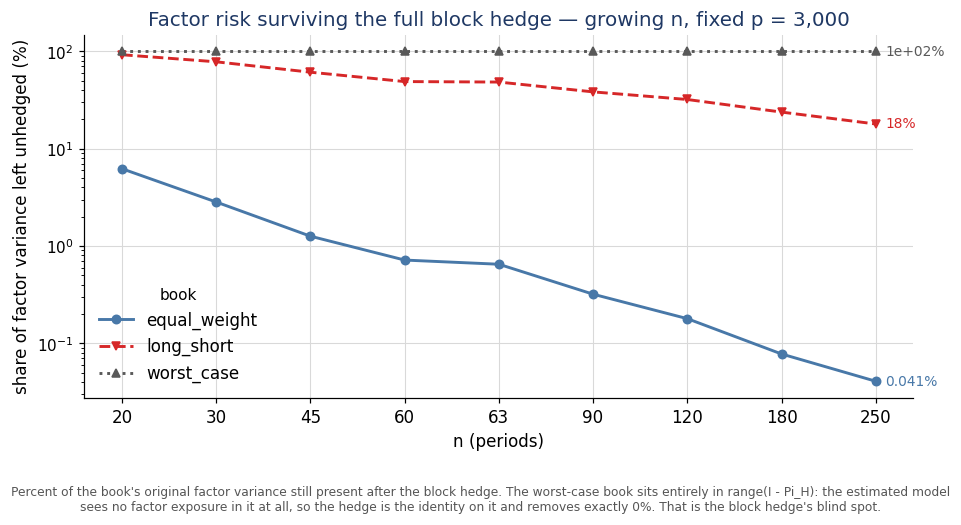

In [11]:
# ── Figure 7 · how much factor risk actually survives the block hedge ────────
d, key, lab = df_n, "n", "growing n, fixed p = 3,000"
ax_spec = sweep_axis(d, key)
full = d[d.j == K].copy()
full["var_frac"] = full.resid_factor_var / full.unhedged_factor_var

fig, ax = plt.subplots(figsize=(8.8, 4.3))
for book, color, mk, ls in (("equal_weight", C_SUB, "o", "-"),
                            ("long_short", C_EST, "v", "--"),
                            ("worst_case", C_REF, "^", ":")):
    s = summarize(full[full.portfolio == book], ax_spec, "var_frac")
    ax.plot(ax_spec.x, 100 * s["mean"], ls=ls, marker=mk, ms=5.5, lw=1.9, color=color, label=book)
    ax.annotate(f"{100*s['mean'].iloc[-1]:.2g}%", xy=(ax_spec.x[-1], 100 * s["mean"].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", fontsize=9, color=color, va="center")
ax.set_yscale("log")
ax.set_xticks(ax_spec.x, ax_spec.cats, fontsize=THEME.tick_fontsize)
style(ax, xlabel=ax_spec.xlabel, ylabel="share of factor variance left unhedged (%)",
      title=f"Factor risk surviving the full block hedge — {lab}")
ax.legend(fontsize=THEME.legend_fontsize, frameon=False, loc="lower left", title="book")
caption(fig, "Percent of the book's original factor variance still present after the block hedge. The worst-case "
             "book sits entirely in range(I - Pi_H): the estimated model sees no factor exposure in it at all, so "
             "the hedge is the identity on it and removes exactly 0%. That is the block hedge's blind spot.")
show(fig, "h1_fig7_variance_surviving")

---
## 5 · Numbers

In [12]:
full_p, full_n = df_p[df_p.j == K], df_n[df_n.j == K]
print("=== invariance of the block hedge (should be ~1e-16) ===")
for d, key, lab in SWEEPS:
    f = d[d.j == K]
    print(f"  {lab:32s} max |resid - resid_relabelled| = "
          f"{(f.total_exposure - f.total_exposure_rot).abs().max():.2e}")
print(f"  oracle hedge residual exposure (all rows)  = "
      f"{max(df_p.oracle_total_exposure.max(), df_n.oracle_total_exposure.max()):.2e}")

print("\n=== partial hedges are NOT invariant (mean |change| under relabelling) ===")
for d, key, lab in SWEEPS:
    chg = (d[d.portfolio == BOOK].assign(delta=lambda x: (x.target_exposure - x.target_exposure_rot).abs())
             .groupby("j")["delta"].mean())
    print(f"  {lab:32s} " + "  ".join(f"m={m}: {v:.4f}" for m, v in chg.items()))

print("\n=== ceilings vs realized, full block, growing n (p = 3,000) ===")
tbl = (full_n.groupby(["n", "portfolio"])[["total_exposure"]].mean().unstack()
       .droplevel(0, axis=1))
tbl["ceiling_tight"] = full_n.groupby("n")["ceiling_tight"].mean()
tbl["ceiling_measured"] = full_n.groupby("n")["ceiling_measured"].mean()
tbl["ceiling_estimable"] = full_n.groupby("n")["ceiling_estimable"].mean()
display(tbl.round(4))

print("=== Corollary 1: how well does the observable statistic track the truth? ===")
acc = (full_n.groupby("n")[["oos_sum", "ell_over_theta_sum"]].mean()
       .assign(ratio=lambda x: x.ell_over_theta_sum / x.oos_sum))
display(acc.round(4))

=== invariance of the block hedge (should be ~1e-16) ===
  growing p, fixed n = 63          max |resid - resid_relabelled| = 2.29e-15
  growing n, fixed p = 3,000       max |resid - resid_relabelled| = 3.71e-15
  oracle hedge residual exposure (all rows)  = 3.64e-15

=== partial hedges are NOT invariant (mean |change| under relabelling) ===
  growing p, fixed n = 63          m=1: 0.8142  m=2: 0.8136  m=3: 0.0000
  growing n, fixed p = 3,000       m=1: 0.8088  m=2: 0.8090  m=3: 0.0000

=== ceilings vs realized, full block, growing n (p = 3,000) ===


portfolio,equal_weight,long_short,worst_case,ceiling_tight,ceiling_measured,ceiling_estimable
n,,,,,,
20,0.2234,0.0159,0.8726,0.8726,1.2565,1.2030
30,0.1533,0.0151,0.8055,0.8055,1.1346,1.0998
45,0.1035,0.0139,0.7302,0.7302,1.0080,0.9841
60,0.0780,0.0129,0.6750,0.6750,0.9190,0.9004
63,0.0743,0.0130,0.6641,0.6641,0.9032,0.8855
90,0.0521,0.0120,0.5909,0.5909,0.7941,0.7809
120,0.0391,0.0110,0.5320,0.5320,0.7094,0.6987
180,0.0257,0.0096,0.4529,0.4529,0.5995,0.5914
250,0.0187,0.0085,0.3941,0.3941,0.5195,0.5129


=== Corollary 1: how well does the observable statistic track the truth? ===


,oos_sum,ell_over_theta_sum,ratio
n,,,
20,1.5815,1.4491,0.9163
30,1.2893,1.2113,0.9395
45,1.0176,0.9697,0.9529
60,0.8458,0.8118,0.9599
63,0.8170,0.7851,0.9609
90,0.6315,0.6105,0.9668
120,0.5038,0.4887,0.9700
180,0.3598,0.3501,0.9730
250,0.2701,0.2633,0.9748


---
## 6 · What this does and does not establish

**Established here, numerically:**

1. $\sum_j\sin^2\angle(h_j,\mathcal{B})=k-\lVert M\rVert_F^2$ is invariant to every
   rotation of the estimated frame, to machine precision — including a rotation
   optimized to make the pairwise error as large as it can be ($=k$, every factor
   at $\pi/2$). *Fig. 1.*
2. The regression hedge a manager actually runs equals $(I-\Pi_H)w$ exactly, so
   the hedged **book** — not just its risk — is invariant to that rotation. *§2.*
3. Across the whole $(n,p)$ grid and every book, the full-block mis-hedge under a
   relabelled frame matches the original to $\sim10^{-16}$, while partial hedges
   move materially. *Fig. 3, §5.*
4. The surviving mis-hedge is bounded by $\sin\theta_{\max}\le\sqrt{\sum_j\sin^2\angle(h_j,\mathcal{B})}$,
   tracked from data alone by $\sqrt{\sum_j\hat\ell/\hat\theta_j}$. *Fig. 5.*

**Caveats, both of which the simulations bear out rather than paper over:**

- **Only the full block is safe.** $m<k$ is still a pairwise construction and the
  relabelled frame damages it (Fig. 3, left two panels). Running $k$ single-factor
  books and summing their *mis-hedges* does not rescue this: the individual errors
  point in unrelated directions and do not cancel. (When the books are built off
  the same orthonormal PCs, the summed *trade* does coincide with the block hedge
  — the distinction that matters is whether the manager commits to an
  interpretation of the individual directions.)
- **The blind spot is structural.** The worst case is attained by a book the
  *estimated* model reports as already factor-neutral ($\Pi_H w=0$), so the
  block hedge does nothing to it at all — it keeps 100% of its factor variance
  (Fig. 7). Nothing in the fit flags this; only the ceiling bounds it.
- **A ceiling is not a loss.** The realized mis-hedge for a specific book on a
  specific day needs $B$ and stays unobservable. What becomes estimable is the
  worst case over books — attained only by the adversarial `worst_case` book, and
  loose by up to $\sqrt{k}$ relative to $\sin\theta_{\max}$. Fig. 5 shows the
  `long_short` book running orders of magnitude under it. At short windows
  ($n\lesssim 45$ here) the Corollary 1 ceiling exceeds 1 and is therefore
  vacuous on its own — it should be read as $\min(\cdot,1)$.
- **$p$ does not help.** The floor is set by $n$ (Fig. 6). A wider universe buys
  no protection.

**So the practical reading of the note holds:** a manager hedging a whole factor
block is exposed to the out-of-subspace error only, and the Stiefel-style
pairwise risk in Examples 1–3 overstates what they face. The out-of-subspace
floor is real, is set by the estimation window, and comes with a data-driven
ceiling — which is a materially better position than one carrying an
unconstrained rotation term.

**Next, if this is worth pursuing:** repeat under the heavy-tailed return process
used in ex-2/ex-3 (`student_t` factor/idio draws) to confirm none of this leans on
Gaussianity; and test a *misspecified* $k$, where the estimated block does not
match the true factor count — the one case where "hedge the whole block" is
ill-defined and the invariance argument has no purchase.